# House Price Prediction - Exploratory Analysis

## About the dataset
This dataset contains 4,600 historical property sales records, primarily focused on the Washington State real estate market (including Seattle, Bellevue, Redmond, and surrounding areas). It provides a comprehensive overview of how structural, historical, and geographic features impact property valuation.

## Columns
* `date` - The specific date when the real estate transaction was recorded (Format: YYYY-MM-DD)
* `price` - The final sale price of the property in USD (Target Variable)
* `bedrooms` - The total number of bedrooms in the property
* `bathrooms` - The total number of bathrooms. Fractional values (e.g., 1.5, 2.25) indicate partial baths (e.g., a toilet and sink                 but no shower)
* `sqft_living` - The total interior square footage of the living space
* `sqft_lot` - The total square footage of the land or lot the property sits on
* `floors` - The number of stories or levels in the property
* `waterfront` - A binary indicator (1 or 0) denoting whether the property has a waterfront
* `view` - A rated index (0 to 4) indicating the overall quality of the property's view
* `condition` - A rated index (1 to 5) indicating the overall structural and aesthetic condition of the property

## Context 
Exploratory data analysis of real estate sales in Washington State. The goal is to understand which factors are associated with home prices and, using a simple example, to demonstrate how EDA results could be used by a real estate agency when selecting cities for expansion.

## Questions
1. What is the overall data quality: are there missing values, duplicates, or anomalies 
   (e.g., `price == 0`), and how should they be handled?
2. How is the price (`price`) distributed, and are there any outliers?
3. Which features correlate most strongly with price (`sqft_living`, 
   `bedrooms`, `bathrooms`, etc.)?
4. How does price vary by city (`city`)—are there clear leaders 
   and laggards in terms of median price and `price_per_sqft`?
5. Do `waterfront`, `view`, and renovation status (`yr_renovated`) 
   affect the house price?

# Libraries Import

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Loading

In [4]:
data = pd.read_csv('../data/modified_data.csv')
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


# Data Quality

In [40]:
print('Missing values:')
print()
print(data.isna().sum())
print('=' * 42)
print(f'Duplicated values: {data.duplicated().sum()}')
print('=' * 42)
print('Datatypes:')
print()
print(data.dtypes)

Missing values:

date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
street            0
city              0
statezip          0
price_per_sqft    0
dtype: int64
Duplicated values: 0
Datatypes:

date               object
price             float64
bedrooms          float64
bathrooms         float64
sqft_living         int64
sqft_lot            int64
floors            float64
waterfront          int64
view                int64
condition           int64
sqft_above          int64
sqft_basement       int64
yr_built            int64
yr_renovated        int64
street             object
city               object
statezip           object
price_per_sqft    float64
dtype: object


In [42]:
data.describe().style.format(precision=1)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0
mean,551963.0,3.4,2.2,2139.3,14852.5,1.5,0.0,0.2,3.5,1827.3,312.1,1970.8,808.6,265.9
std,563834.7,0.9,0.8,963.2,35884.4,0.5,0.1,0.8,0.7,862.2,464.1,29.7,979.4,357.5
min,0.0,0.0,0.0,370.0,638.0,1.0,0.0,0.0,1.0,370.0,0.0,1900.0,0.0,0.0
25%,322875.0,3.0,1.8,1460.0,5000.8,1.0,0.0,0.0,3.0,1190.0,0.0,1951.0,0.0,180.8
50%,460943.5,3.0,2.2,1980.0,7683.0,1.5,0.0,0.0,3.0,1590.0,0.0,1976.0,0.0,243.9
75%,654962.5,4.0,2.5,2620.0,11001.2,2.0,0.0,0.0,4.0,2300.0,610.0,1997.0,1999.0,314.8
max,26590000.0,9.0,8.0,13540.0,1074218.0,3.5,1.0,4.0,5.0,9410.0,4820.0,2014.0,2014.0,22533.9


In [43]:
(data['price'] == 0).sum()

np.int64(49)

In [44]:
(data['bedrooms'] == 0).sum()

np.int64(2)

In [45]:
data[data['price_per_sqft'] == 22533.9]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
4350,2014-07-03,26590000.0,3.0,2.0,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,22533.9


# Data Quality Report

* 49 sales recorded at $0. 
* `date` column have the wrong format. *Object* instead of *Datetime*
* 22533.9 per sqft is roughly 70x the dataset median(265.9/sqft). Most likely it's a data entry error (e.g., a misplaced decimal)
* 2 sales with 0 bedrooms. Plausible for land-value sales
* No missing values and no duplicate rows were found

In [46]:
dq_report = pd.DataFrame({
    'Issue': [
        'Zero-price listings',
        'Extreme price (>$2000/sqft)',
        'Zero-bedroom listngs',
        'Missing values',
        'Duplicated rows'],
    'Rows Affected': [
        (data['price'] == 0).sum(),
        (data['price_per_sqft'] > 2000).sum(),
        (data['bedrooms'] == 0).sum(),
        data.isna().sum().sum(),
        data.duplicated().sum()]  
})
dq_report['% of dataset'] = (dq_report['Rows Affected'] / len(data) * 100).round(2)
dq_report

,Issue,Rows Affected,% of dataset
0,Zero-price listings,49,1.07
1,Extreme price (>$2000/sqft),2,0.04
2,Zero-bedroom listngs,2,0.04
3,Missing values,0,0.00
4,Duplicated rows,0,0.00


# Data Cleaning

* Drop rows with $0 sales
* Drop rows with `price_per_sqft` > 2000
* Keep 0-bedroom listings

In [5]:
df = data[(data['price'] != 0) & (data['price_per_sqft'] <= 2000)].copy()

In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Feature Engineering

### New features engineered for analysis:
* house_age - years between build year and sale year
* was_renovated - binary flag: 1 - Yes, 0 - No
* has_basement - binary flag: 1 - Yes, 0 - No

In [7]:
df['house_age'] = df['date'].dt.year - df['yr_built']
df['was_renovated'] = (df['yr_renovated'] != 0).astype(int)
df['has_basement'] = (df['sqft_basement'] != 0).astype(int)

# Exploratory Analysis

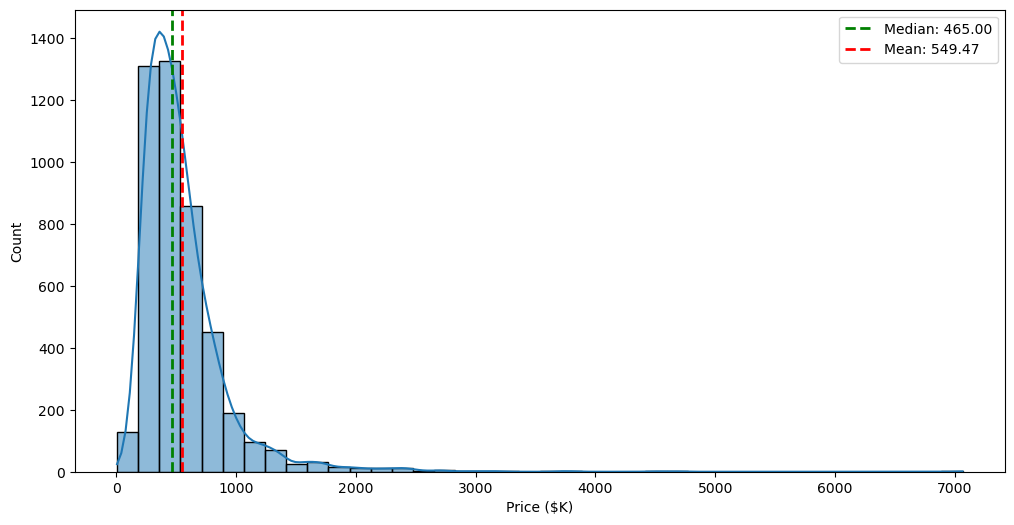

In [55]:
plt.figure(figsize=(12,6))

ax = sns.histplot(df['price'] / 1000, bins=40, kde=True)

median_val = (np.median(df['price'])) / 1000
mean_val = (np.mean(df['price'])) / 1000

plt.axvline(
    median_val,
    color='green',
    linestyle='--',
    linewidth=2,
    label = f'Median: {median_val:.2f}'
)
plt.axvline(
    mean_val, 
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_val:.2f}'
)

plt.xlabel('Price ($K)')
plt.legend()
plt.show()

Text(0.5, 0, 'Price ($K)')

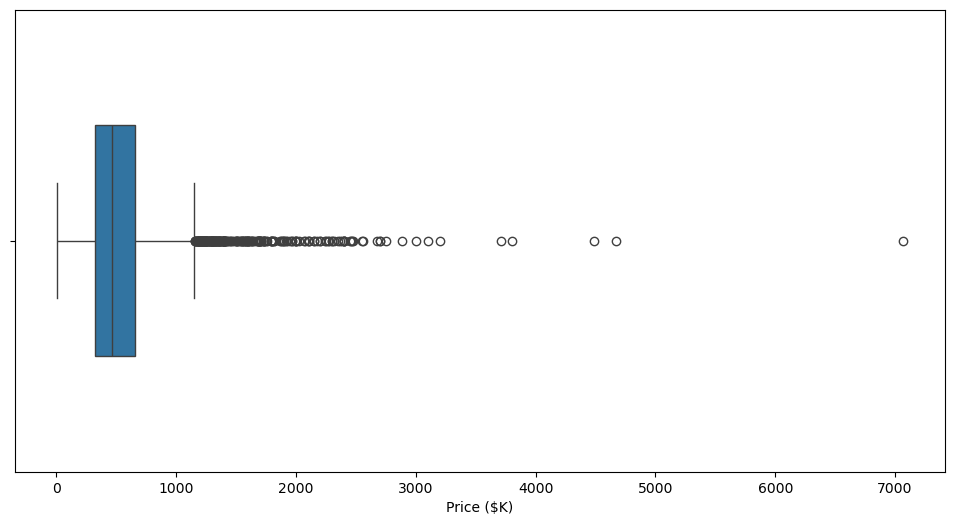

In [127]:
plt.figure(figsize=(12,6))
sns.boxplot(x=(df['price']) / 1000, width=.5)
plt.xlabel('Price ($K)')

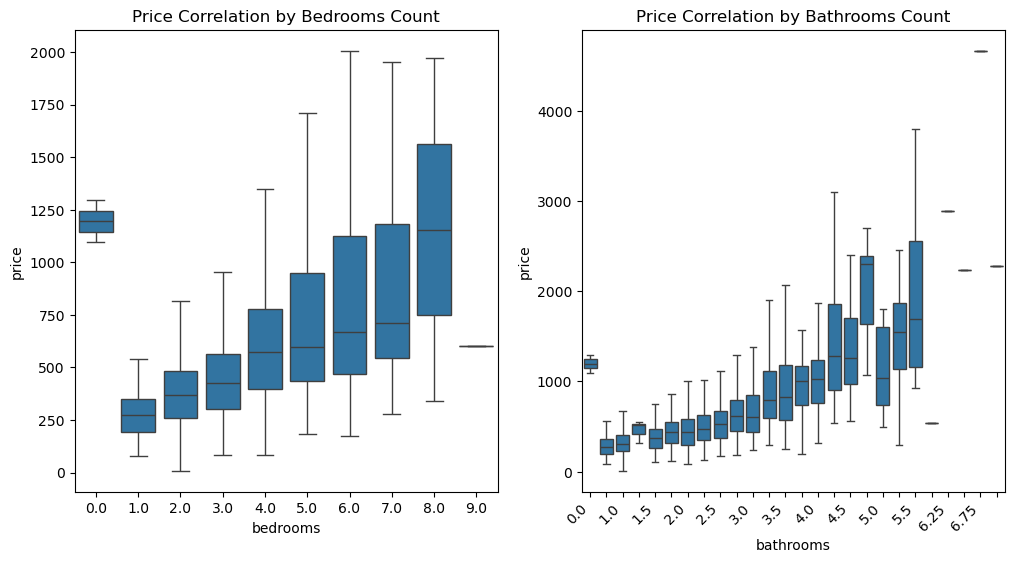

In [187]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x=df['bedrooms'], y=(df['price']) / 1000, ax=ax[0], showfliers=False)
sns.boxplot(x=df['bathrooms'], y=(df['price']) / 1000, ax=ax[1], showfliers=False)

ax[0].set_title('Price Correlation by Bedrooms Count')
ax[1].set_title('Price Correlation by Bathrooms Count')
ax[1].set_xticks(ax[1].get_xticks())
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha="right")

for index, label in enumerate(ax[1].xaxis.get_ticklabels()):
    if index % 2 != 0:
        label.set_visible(False)

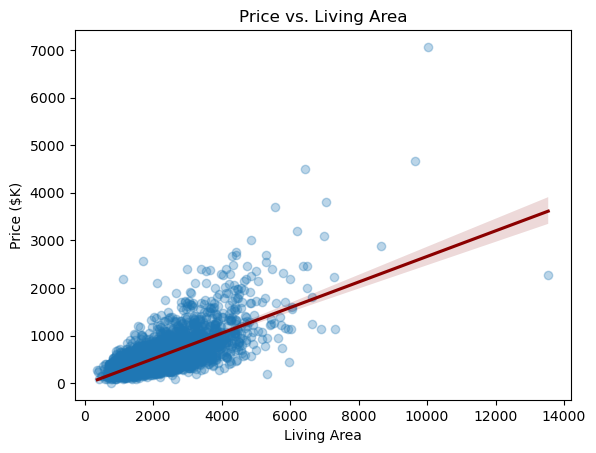

In [182]:
sns.regplot(x=df['sqft_living'], y=(df['price'] / 1000), scatter_kws={'alpha': .3}, line_kws={'color': 'darkred'} )
plt.title('Price vs. Living Area')
plt.xlabel('Living Area')
plt.ylabel('Price ($K)')
plt.show()

In [10]:
num_cols = ['price',
            'bedrooms',
            'bathrooms',
            'sqft_living',
            'sqft_lot',
            'floors',
            'waterfront',
            'view',
            'condition',
            'sqft_above',
            'sqft_basement',
            'yr_built',
            'yr_renovated',
            'price_per_sqft'
           ]

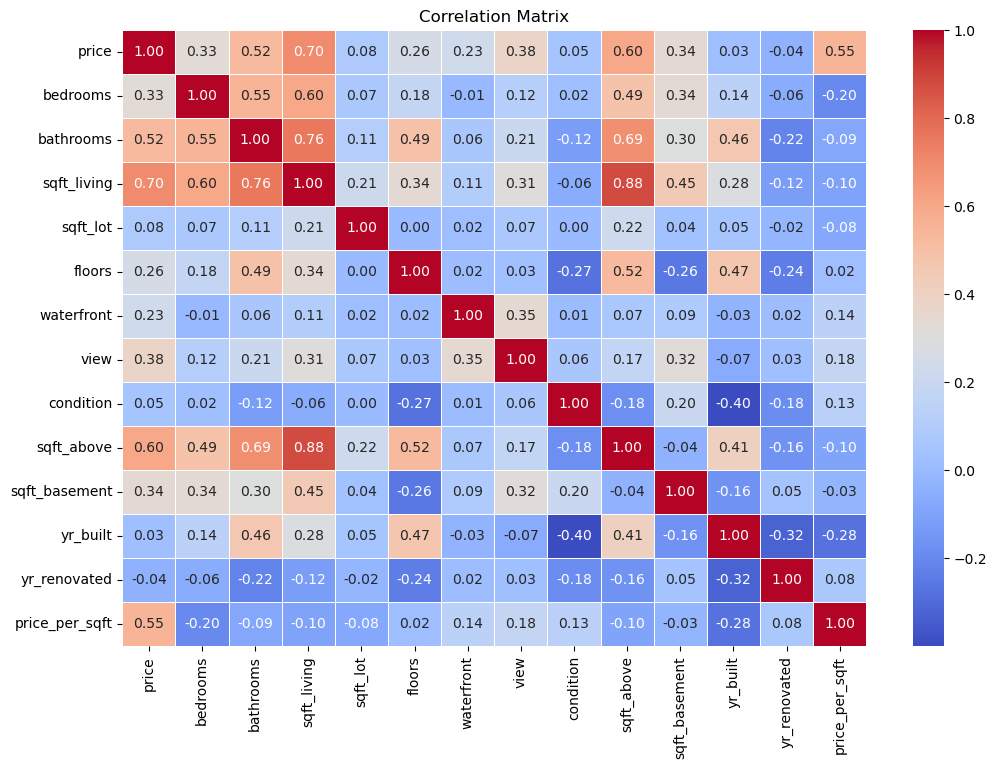

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

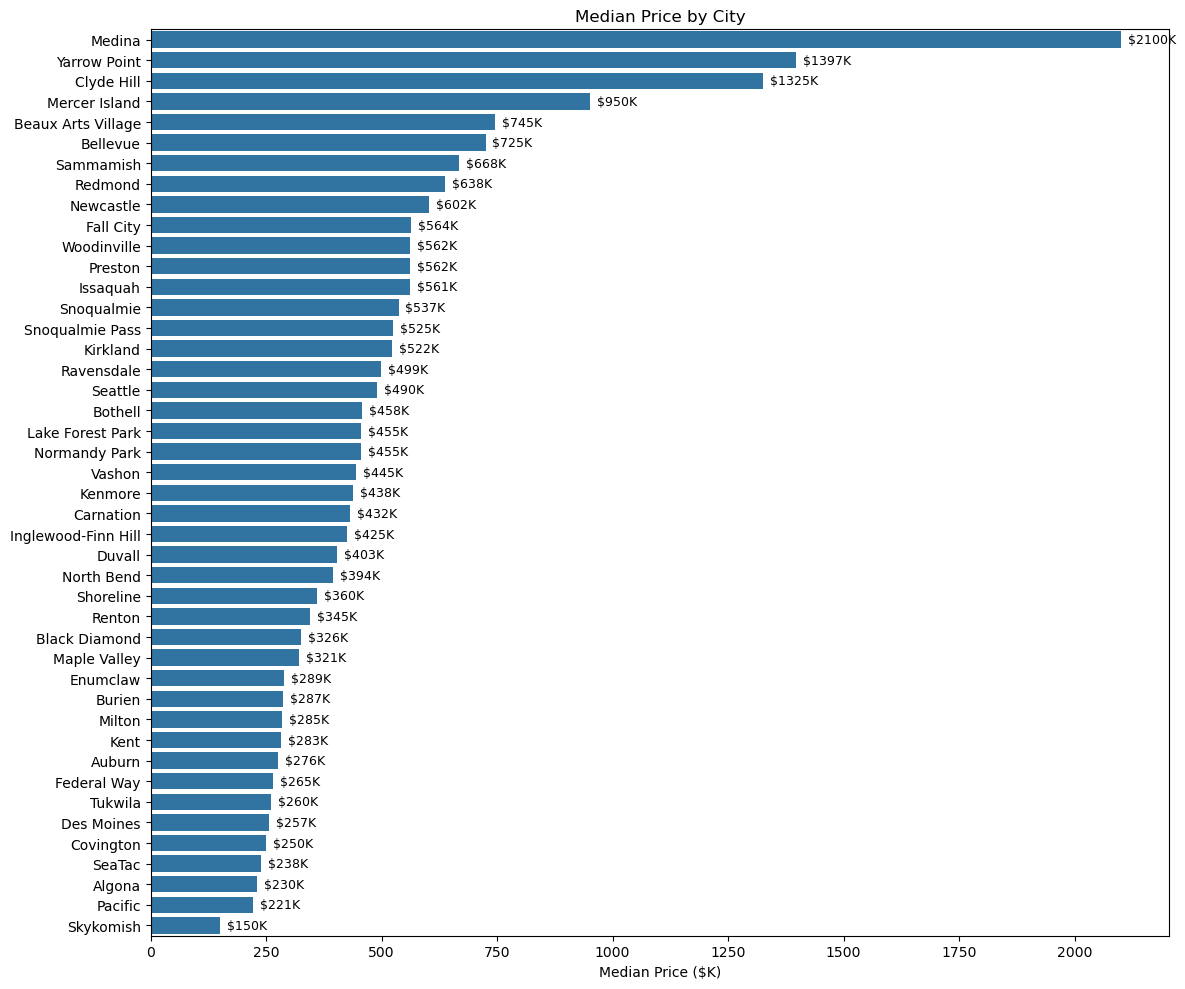

In [12]:
city_stats = df.groupby('city')['price'].agg(['median','count']).sort_values('median', ascending=False)
city_stats_scaled = city_stats['median'] / 1000

plt.figure(figsize=(12, 10))

sns.barplot(x=city_stats_scaled, y=city_stats.index)

plt.title('Median Price by City')
plt.xlabel('Median Price ($K)')
plt.ylabel('')

for container in plt.gca().containers:
    labels = [f"${v.get_width():.0f}K" for v in container]
    plt.gca().bar_label(container, labels=labels, padding=5, fontsize=9)

plt.tight_layout()
plt.show()

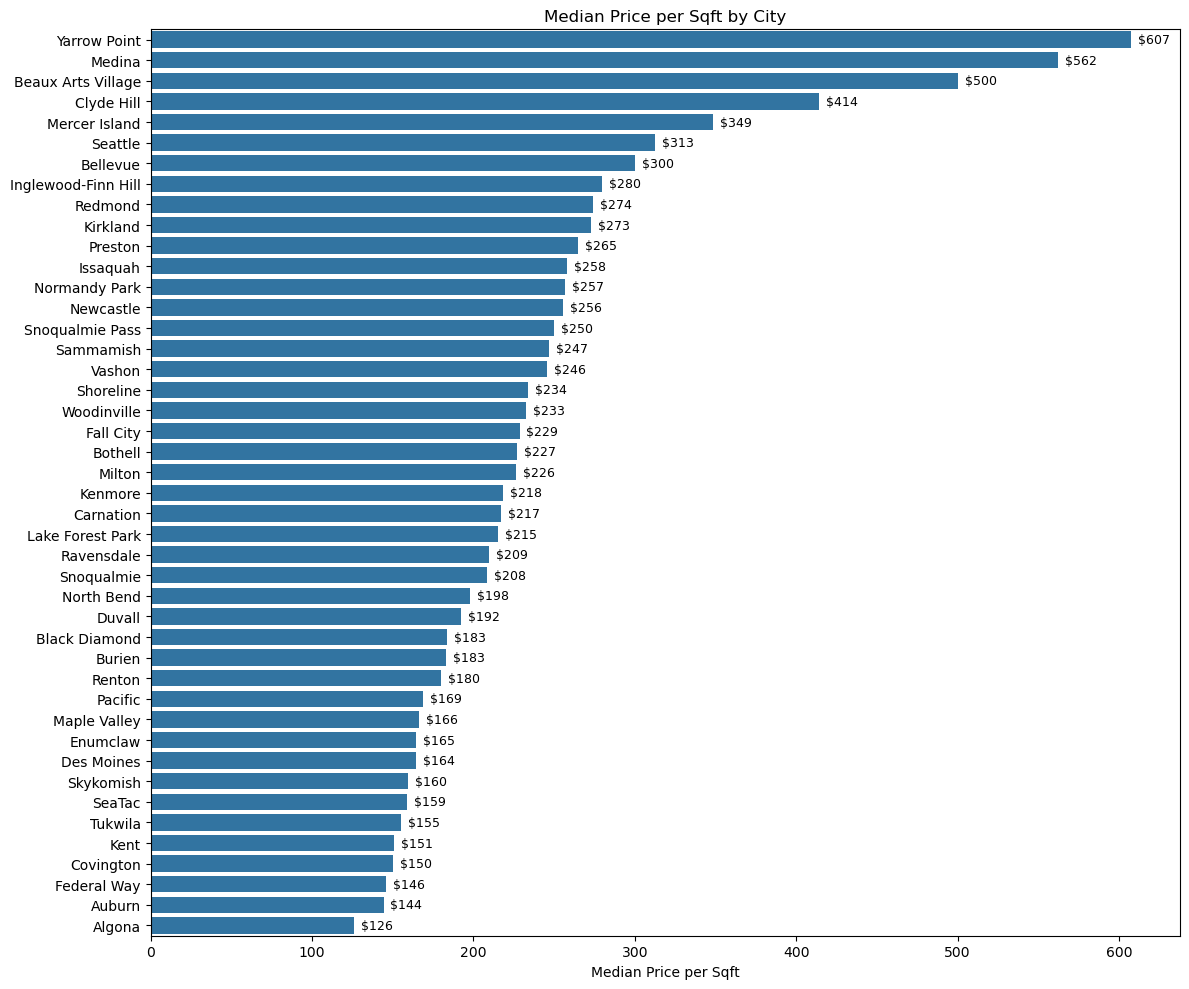

In [35]:
plt.figure(figsize=(12, 10))

city_order = df.groupby('city')['price_per_sqft'].median().sort_values(ascending=False).index

sns.barplot(x=df['price_per_sqft'], y=df['city'], order=city_order, errorbar=None, estimator='median')

plt.title('Median Price per Sqft by City')
plt.xlabel('Median Price per Sqft')
plt.ylabel('')

for container in plt.gca().containers:
    labels = [f"${v.get_width():.0f}" for v in container]
    plt.gca().bar_label(container, labels=labels, padding=5, fontsize=9)

plt.tight_layout()
plt.show()

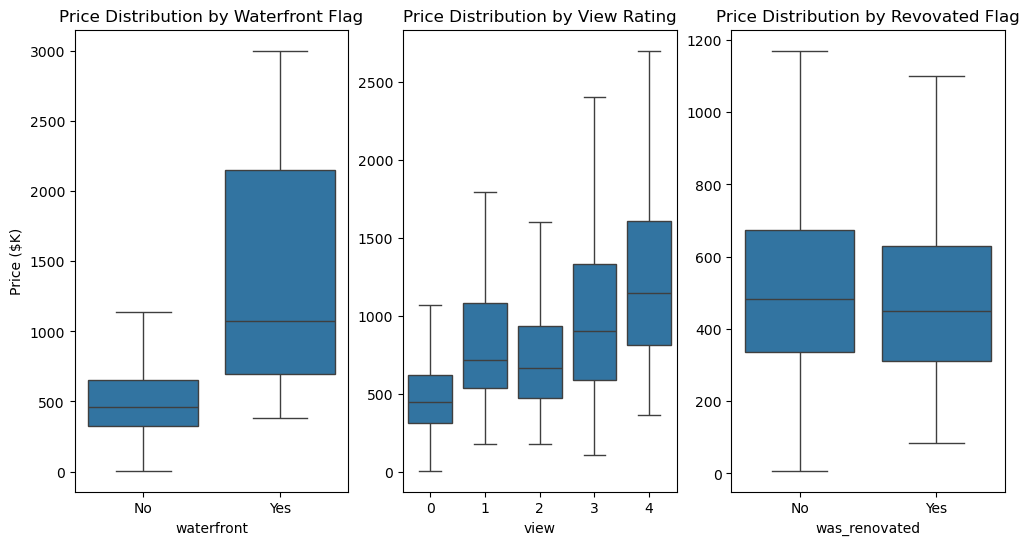

In [52]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

sns.boxplot(x=df['waterfront'], y=(df['price']) / 1000, ax=ax[0], showfliers=False)
sns.boxplot(x=df['view'], y=(df['price'] / 1000), ax=ax[1], showfliers=False)
sns.boxplot(x=df['was_renovated'], y=(df['price']) / 1000, ax=ax[2], showfliers=False)

ax[0].set_title('Price Distribution by Waterfront Flag')
ax[0].set_ylabel('Price ($K)')
ax[0].set_xticks(ax[0].get_xticks())
ax[0].set_xticklabels(['No', 'Yes'])

ax[1].set_title('Price Distribution by View Rating')
ax[1].set_ylabel('')

ax[2].set_title('Price Distribution by Revovated Flag')
ax[2].set_ylabel('')
ax[2].set_xticks(ax[2].get_xticks())
ax[2].set_xticklabels(['No', 'Yes'])

plt.show()

# Summary Report

## 1. Data Quality
The dataset arrived clean in the technical sense — no missing values and no duplicate rows across all 4,600 records. Three issues needed handling before analysis:
- **49 listings (1.1%) priced at \\$0** — not genuine market transactions (likely gifts, foreclosures, or placeholder entries) and were removed.
- **1 extreme outlier** — a \\$26.59M sale in Kent at \\$22,534/sqft, roughly 70x the dataset median of \\$266/sqft. Combined with a second borderline row, 2 rows (0.04%) exceeding \\$2,000/sqft were removed as data-entry errors.
- **2 listings (0.04%) with 0 bedrooms** were kept — plausible as land-value or teardown sales rather than data errors.
- The `date` column was stored as text and converted to a proper datetime type.

After cleaning, 4,549 rows (98.9% of the original data) remained for analysis.

## 2. Price Distribution
Price is right-skewed: the median sits at **\\$465K** while the mean is pulled up to **\\$549K** by a long tail of high-value sales reaching as high as \\$7.06M. The boxplot shows the “normal” market sitting below roughly \\$1.15M, with a sizeable cluster of luxury outliers above that. **Median, not mean, is the more representative summary statistic for this market.**

## 3. Price Correlations
Living space is the strongest real driver of price: `sqft_living` (r = 0.70), `sqft_above` (r = 0.60), and `bathrooms` (r = 0.52) all show a moderate positive relationship. `view` (0.38) and `bedrooms` (0.33) matter less. Lot size, condition, build year, and renovation year all show **near-zero correlation** with price (all |r| ≤ 0.8) — size and amenity quality, not age or lot size, drive value in this market.

## 4. Price by City
City is the single biggest lever on price. Median prices range from **\\$2.10M in Medina down to \\$150K in Skykomish** — a 14x spread.
- **Leaders:** Medina, Yarrow Point, Clyde Hill, Mercer Island, Beaux Arts Village, Bellevue — the Eastside's lakefront/exclusive enclaves.
- **Laggards:** Skykomish, Pacific, Algona, SeaTac, Covington, Des Moines.
- Ranked by **price per sqft**, Yarrow Point (\\$607) actually edges out Medina (\\$562), suggesting smaller homes on an even steeper land premium. Seattle doesn't top the absolute-price list (#17 at \\$490K) but ranks #6 by price/sqft (\\$313), reflecting dense urban demand.

## 5. Waterfront, View & Renovation
- **Waterfront** is the strongest categorical price signal after city: median price roughly **doubles** (\~\\$450K → \~\\$1.05M+) for waterfront properties, with a much wider spread.
- **View rating** shows a clean, monotonic relationship: median price climbs steadily from view=0 (\~\\$450K) to view=4 (\~\\$1.2M).
- **Renovation status**, counter-intuitively, shows almost no price premium — renovated homes have a similar or even slightly lower median price than non-renovated ones, matching its near-zero correlation with price. This likely reflects that renovation is more common on older homes catching up to market standard, rather than adding value on top of an already-updated home — it isn't a reliable standalone price signal.
